[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giordamaug/Embed_Clinical_Sequences_Asplenic/blob/main/notebook.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/giordamaug/Embed_Clinical_Sequences_Asplenic/HEAD?urlpath=%2Fdoc%2Ftree%2Fnotebook.ipynb)

# Experiments

## Libraries

In [7]:
import torch
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
from sklearn.metrics import (
    matthews_corrcoef, confusion_matrix, accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
import lightgbm as lgb
import seaborn as sns
from tqdm.notebook import tqdm
import sys, os
import random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"       # to force BERT determinsm

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # per multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


## Download data from Github

In [8]:
try:
    import google.colab
    !git clone https://github.com/giordamaug/Embed_Clinical_Sequences_Asplenic.git
    %cd Embed_Clinical_Sequences_Asplenic
    print("Working on Colab!")
except:
    pass

## Load dataset

In [9]:
import pandas as pd
df = pd.read_json(f"data/dataset_EN.json").set_index("id")

### Cohort selection and settings

In [10]:
groupname = "NTDT+TDT"         # patient groups: ALL, NTDT+TDT
subgroup = ""                  # no subgroup selection
selected_ids = pd.read_csv(f"config/{groupname}_index.csv", header=None).values.ravel()
results_dir = "results"   # in "results_rev2" you find paper's results
niter = 1                 # number of repeated cv
num_epochs = 10           # number of epochs for training
batch_size = 32           # batch size in training
embedding_dim = 64        # embedding size
hidden_dim = 128
seed = 42
enable_plot = True
methods=['STATIC', 'BINARY', 'DOME', 'LSTM', 'tLSTM', 'GRU', 'GRU-D', 'BEHRT', 'RETAIN', 'Dipole']
dataset = df.loc[selected_ids]
dataset

,is_splenectomized?,qt_vax_prophylaxis,days_after,days_before,qt_vax_post_prophylaxis,tsh,dosage_num,qt_vax_totali,smoking,dyslipidemia,...,splenectomy_indication,splenectomy_method,primary_disease,prophylaxis_vax_hib,prophylaxis_vax_flu,prophylaxis_vax_meningo,prophylaxis_vax_pneumo,splenectomy_response,gender,events
id,,,,,,,,,,,,,,,,,,,,,
16,1,2,0.0,0.0,0,NaN,-1000.0,2,0.0,0.0,...,NaN,0.0,3,1,0,0,1,NaN,0,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
42,1,0,0.0,0.0,3,NaN,-1000.0,3,0.0,0.0,...,NaN,1.0,1,0,0,0,0,NaN,1,"[{'type': 'therapy', 'event': 'antibiotic', 'd..."
43,1,3,0.0,0.0,4,NaN,-1000.0,7,0.0,0.0,...,NaN,1.0,1,1,0,1,1,NaN,0,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
48,1,6,0.0,0.0,0,NaN,-1000.0,6,0.0,0.0,...,NaN,1.0,1,1,0,1,1,NaN,1,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
49,1,2,0.0,0.0,0,NaN,-1000.0,2,0.0,0.0,...,NaN,0.0,1,1,0,0,1,NaN,0,"[{'type': 'vaccination', 'event': 'Pneumo23', ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1921,1,2,0.0,0.0,4,NaN,-1000.0,6,0.0,0.0,...,0.0,NaN,1,0,0,1,1,2.0,1,"[{'type': 'vaccination', 'event': 'Pneumo23', ..."
1922,1,0,0.0,0.0,0,1.13,-1000.0,0,0.0,0.0,...,NaN,NaN,3,0,0,0,0,NaN,0,"[{'type': 'surgical operation', 'event': 'sple..."
1924,1,0,0.0,0.0,2,NaN,-1000.0,2,0.0,0.0,...,3.0,0.0,1,0,0,0,0,NaN,0,"[{'type': 'therapy', 'event': 'transfusion', '..."


### plot disease distributions

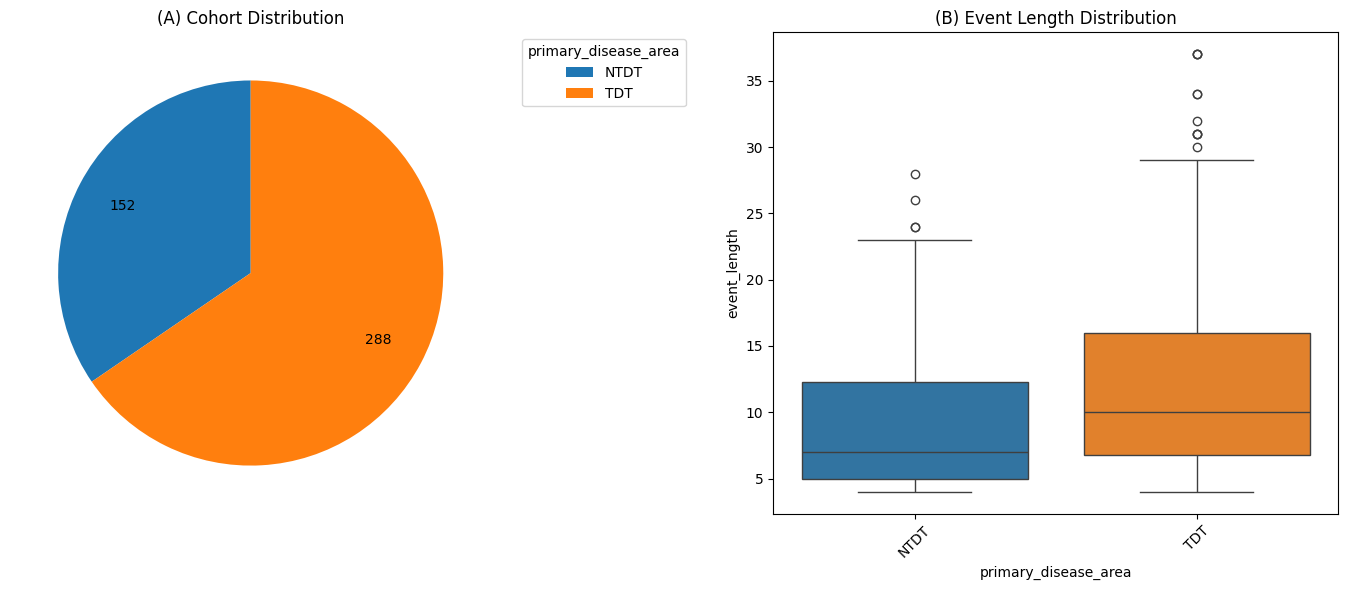

In [11]:
from plotting import plot_group_distribution_with_event_boxplot

label_desc = ['CHA','SCD','TDT','NTDT','AIDH','NHOC','OC','AS','IM']
plot_group_distribution_with_event_boxplot(dataset, groupby='primary_disease_area', label_desc=label_desc)

## Refine by subgroups

In [12]:
selected_ids = dataset.index
if subgroup == "male":
    selected_ids = dataset[dataset["gender"] == 0].index.values
    plot_group_distribution_with_event_boxplot(dataset, groupby='gender', label_desc=['male', 'female'])
elif subgroup == "female":
    plot_group_distribution_with_event_boxplot(dataset, groupby='gender', label_desc=['male', 'female'])
    selected_ids = dataset[dataset["gender"] == 1].index.values
elif subgroup == "pediatric":
    plot_group_distribution_with_event_boxplot(dataset, groupby='age_group', label_desc=['pediatric', 'adolescent','adult'])
    selected_ids = dataset[dataset["age_group"] == 0].index.values
elif subgroup == "adolescent":
    plot_group_distribution_with_event_boxplot(dataset, groupby='age_group', label_desc=['pediatric', 'adolescent','adult'])
    selected_ids = dataset[dataset["age_group"] == 1].index.values
elif subgroup == "adult":
    plot_group_distribution_with_event_boxplot(dataset, groupby='age_group', label_desc=['pediatric', 'adolescent','adult'])
    selected_ids = dataset[dataset["age_group"] == 2].index.values
elif subgroup == "laparoscopy":
    plot_group_distribution_with_event_boxplot(dataset, groupby='splenectomy_method', label_desc=['laparotomy', 'laparoscopy'])
    selected_ids = dataset[dataset["splenectomy_method"] == 0.0].index.values
elif subgroup == "laparotomy":
    plot_group_distribution_with_event_boxplot(dataset, groupby='splenectomy_method', label_desc=['laparotomy', 'laparoscopy'])
    selected_ids = dataset[dataset["splenectomy_method"] == 1.0].index.values
dataset = df.loc[selected_ids]
dataset

,is_splenectomized?,qt_vax_prophylaxis,days_after,days_before,qt_vax_post_prophylaxis,tsh,dosage_num,qt_vax_totali,smoking,dyslipidemia,...,splenectomy_indication,splenectomy_method,primary_disease,prophylaxis_vax_hib,prophylaxis_vax_flu,prophylaxis_vax_meningo,prophylaxis_vax_pneumo,splenectomy_response,gender,events
id,,,,,,,,,,,,,,,,,,,,,
16,1,2,0.0,0.0,0,NaN,-1000.0,2,0.0,0.0,...,NaN,0.0,3,1,0,0,1,NaN,0,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
42,1,0,0.0,0.0,3,NaN,-1000.0,3,0.0,0.0,...,NaN,1.0,1,0,0,0,0,NaN,1,"[{'type': 'therapy', 'event': 'antibiotic', 'd..."
43,1,3,0.0,0.0,4,NaN,-1000.0,7,0.0,0.0,...,NaN,1.0,1,1,0,1,1,NaN,0,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
48,1,6,0.0,0.0,0,NaN,-1000.0,6,0.0,0.0,...,NaN,1.0,1,1,0,1,1,NaN,1,"[{'type': 'vaccination', 'event': 'Hib', 'date..."
49,1,2,0.0,0.0,0,NaN,-1000.0,2,0.0,0.0,...,NaN,0.0,1,1,0,0,1,NaN,0,"[{'type': 'vaccination', 'event': 'Pneumo23', ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1921,1,2,0.0,0.0,4,NaN,-1000.0,6,0.0,0.0,...,0.0,NaN,1,0,0,1,1,2.0,1,"[{'type': 'vaccination', 'event': 'Pneumo23', ..."
1922,1,0,0.0,0.0,0,1.13,-1000.0,0,0.0,0.0,...,NaN,NaN,3,0,0,0,0,NaN,0,"[{'type': 'surgical operation', 'event': 'sple..."
1924,1,0,0.0,0.0,2,NaN,-1000.0,2,0.0,0.0,...,3.0,0.0,1,0,0,0,0,NaN,0,"[{'type': 'therapy', 'event': 'transfusion', '..."


## Get sequences and static data

In [7]:
from utils import count_events_by_type
ev_fields = ['event']
target_type = "infection"
events_field, date_field, type_field = 'events', 'date', 'type'
removeevents = ['followup', 'platelet_change']
target = 'eventi_infettivi'
attributes = pd.read_csv("config/attributes_EN.csv", header=None, comment = '#', index_col=0).index.to_list()
targets = pd.read_csv("config/targets_EN.csv", index_col=0)

event_sequences_no_trunc_with_type = { id: [(" ".join([event[field] for field in ev_fields]), event[date_field], event[type_field]) for event in events] for (id,events) in dataset[[events_field]].to_dict()[events_field].items()} 
cnt_df = count_events_by_type(event_sequences_no_trunc_with_type)

In [8]:
from utils import group_events_by_visit
# get sequence of event names
event_sequences_no_trunc_with_type = { id: [(" ".join([event[field] for field in ev_fields]), event[date_field], event[type_field]) for event in events if event[type_field] not in removeevents] for (id,events) in dataset[[events_field]].to_dict()[events_field].items()} 
event_sequences_no_trunc = { id: [(" ".join([event[field] for field in ev_fields]), event[date_field]) for event in events if event[type_field] not in removeevents] for (id,events) in dataset[[events_field]].to_dict()[events_field].items()} 
visit_sequences_no_trunc = group_events_by_visit(event_sequences_no_trunc)
print(f"n.{len(event_sequences_no_trunc)} Patients")


n.215 Patients


## Get targets

In [9]:
targets = list(cnt_df.loc[target_type]['set'])
targets

['bacterial infection of the pleural cavities',
 'bacterial infection of the biliary tract',
 'bacterial/viral infection of the ear',
 'bacterial infection of the urogenital system',
 'bacterial infection of the respiratory tract',
 'bacterial infection of the cardiovascular system',
 'bacterial/viral infection of the gastrointestinal system',
 'systemic infection',
 'bacterial/viral infection of the heart',
 'bacterial/viral infection of the joints',
 'viral/automimetic infection of the eye',
 'zoonotic bacterial infection',
 'viral infection of the skin and mucous membranes',
 'bacterial infection of the urinary tract',
 'bacterial/viral infection of the pancreas',
 'bacterial/viral infection of the central nervous system',
 'localised bacterial infection',
 'systemic viral infection',
 'other infection',
 'bacterial infection of the bones',
 'viral infection of the liver',
 'bacterial infection of the gastrointestinal system',
 'bacterial/viral infection of the oral mucous membranes

In [10]:
from utils import count_events_by_type
count_events_by_type(event_sequences_no_trunc_with_type)

,cardinality,n. instances,set
type,,,
vaccination,8,787,"{meningococcus_ACWY, PCV7, meningococcus_B, Hi..."
therapy,27,1072,"{diuretic, antigout, antiarrhythmic, immunosti..."
surgical operation,4,226,"{cholecystectomy, appendectomy, splenectomy, l..."
infection,24,117,"{bacterial infection of the pleural cavities, ..."
comorbidity,15,275,"{tumours and neoplasms, renal and urinary dise..."
thrombosis,3,32,"{arterial/venous thrombosis, arterial thrombos..."


## Truncate sequences on 1st target

In [11]:
from utils import truncate_events_on1st_infection
event_sequences, y_df = truncate_events_on1st_infection(event_sequences_no_trunc_with_type, field_value=target_type)
visit_sequences = group_events_by_visit(event_sequences)

Truncating:   0%|          | 0/215 [00:00<?, ?it/s]

## Configurations

In [12]:
from configure import configure_embedder

# === LSTM vocabulary ===
vocab = set()
for patient_events in event_sequences_no_trunc.values():
    for event,date in patient_events:
        vocab.update([event] if isinstance(event, str) else event)
word_to_idx = {word: idx for idx, word in enumerate(sorted(vocab))}  # for LSTM, RETAIN, etc
# === BEHRT vocabulary ===
code2id = {"[PAD]": 0, "[CLS]": 1, "[SEP]": 2}
idx = 3
for pid, visits in visit_sequences_no_trunc.items():
    for events, date in visits:
        for event in events:
            if event not in code2id:
                code2id[event] = idx
                idx += 1
labels = y_df.to_dict()['target']

embedder_configs = configure_embedder(event_sequences, event_sequences_no_trunc, visit_sequences, labels, targets, dataset,
                                        word_to_idx, code2id, vocab, attributes, num_epochs, batch_size, embedding_dim, hidden_dim, enable_plot)

## Iterated CV (Validation)

In [13]:
from cv_folding import lgbm_cv
import pickle
# Pre-allocate empty DataFrame with correct dtypes
results_df = pd.DataFrame()
rawcols = ['AUC', 'F1', 'Prec', 'Recall', 'MCC', 'Acc', 'Brier', 'CM', 'y_true_oof', 'y_pred_oof', 'y_prob_oof', 'calibration_prob_pred', 'calibration_prob_true']
res = {met: {m: [] for m in methods} for met in rawcols}
for i in range(int(niter)):
    for m in methods:
        set_seed(seed+i)
        results_tmp, model, _,_,_,_, results = lgbm_cv(embedder_configs, y_df, selected_ids, 
                                                       methods=["STATIC"] if m == 'STATIC' else ["STATIC", m], 
                                                       random_state=seed+i, return_metrics=True)
        for metric in res.keys():
            if metric in ['CM', 'y_true_oof', 'y_pred_oof', 'y_prob_oof', 'calibration_prob_pred', 'calibration_prob_true']:
                res[metric][m] += [results[metric].tolist()]
            elif metric == 'Brier':
                res[metric][m] += [results[metric]]
            else:
                res[metric][m] += results[metric]
        results_df = pd.concat([results_df, results_tmp],axis=0)
with open(f"{results_dir}/rawmeas_{niter}iter_{groupname}{subgroup}.pkl", 'wb') as f:
    pickle.dump(res, f)

for metric in res.keys():
    pd.DataFrame(res[metric]).to_csv(f"{results_dir}/resdata_{metric}_{groupname}.csv")
results_df.to_csv(f"{results_dir}/resdata_{niter}iter_{groupname}{subgroup}.csv")

## Print table of performance

In [14]:
import pandas as pd
import numpy as np
metrics = ['AUC', 'F1', 'Prec', 'Recall', 'MCC', 'Acc', 'CM', 'Brier']
dfs = {}
table = {m: [] for m in metrics}
for metric in metrics:
    dfs[metric] = pd.read_csv(f"{results_dir}/resdata_{metric}_{groupname}.csv", index_col=0)
    for method in methods:
        if metric == "CM":
            table[metric] += [dfs[metric][method].apply(lambda x: np.array(eval(x))).sum() / 5]
        else:
            table[metric] += [f"{dfs[metric][method].mean():.3f}+{dfs[metric][method].std():.3f}"]
pd.DataFrame(table, index=methods)

,AUC,F1,Prec,Recall,MCC,Acc,CM,Brier
STATIC,0.822+0.081,0.673+0.112,0.818+0.175,0.635+0.231,0.580+0.107,0.805+0.051,"[[25.4, 3.0], [5.4, 9.2]]",0.167+nan
BINARY,0.885+0.052,0.813+0.101,0.834+0.103,0.798+0.122,0.722+0.155,0.874+0.071,"[[26.0, 2.4], [3.0, 11.6]]",0.130+nan
DOME,0.910+0.050,0.783+0.103,0.776+0.086,0.799+0.155,0.675+0.162,0.851+0.073,"[[25.0, 3.4], [3.0, 11.6]]",0.131+nan
LSTM,0.861+0.014,0.781+0.035,0.750+0.077,0.823+0.057,0.664+0.064,0.842+0.038,"[[24.2, 4.2], [2.6, 12.0]]",0.146+nan
tLSTM,0.749+0.030,0.627+0.075,0.722+0.193,0.647+0.247,0.499+0.035,0.753+0.045,"[[23.0, 5.4], [5.2, 9.4]]",0.193+nan
GRU,0.758+0.097,0.680+0.073,0.699+0.146,0.701+0.134,0.529+0.108,0.777+0.065,"[[23.2, 5.2], [4.4, 10.2]]",0.174+nan
GRU-D,0.799+0.121,0.744+0.170,0.893+0.121,0.648+0.186,0.670+0.201,0.856+0.083,"[[27.4, 1.0], [5.2, 9.4]]",0.150+nan
BEHRT,0.821+0.130,0.718+0.219,0.847+0.114,0.704+0.291,0.652+0.171,0.842+0.076,"[[26.0, 2.4], [4.4, 10.2]]",0.152+nan
RETAIN,0.782+0.061,0.664+0.064,0.841+0.169,0.572+0.105,0.563+0.102,0.805+0.048,"[[26.2, 2.2], [6.2, 8.4]]",0.178+nan
Dipole,0.818+0.058,0.727+0.045,0.802+0.146,0.698+0.134,0.617+0.068,0.823+0.039,"[[25.2, 3.2], [4.4, 10.2]]",0.168+nan


# Model Explainability
## SHAP analysis

In [15]:
from cv_folding import lgbm_cv
results_df, model, X_df, Xv_df, y_train, y_test, results = lgbm_cv(embedder_configs, y_df, selected_ids, methods=["STATIC", "BINARY"], 
                                                                   random_state=seed, return_metrics=True)
results_df

,AUC mean,AUC std,F1 mean,F1 std,Prec mean,Prec std,Recall mean,Recall std,MCC mean,MCC std,Acc mean,Acc std,Brier,CM
STATIC+BINARY,0.885123,0.04619,0.81278,0.090289,0.833727,0.092197,0.798095,0.109279,0.721631,0.138389,0.874419,0.063433,0.130117,"[[130, 12], [15, 58]]"


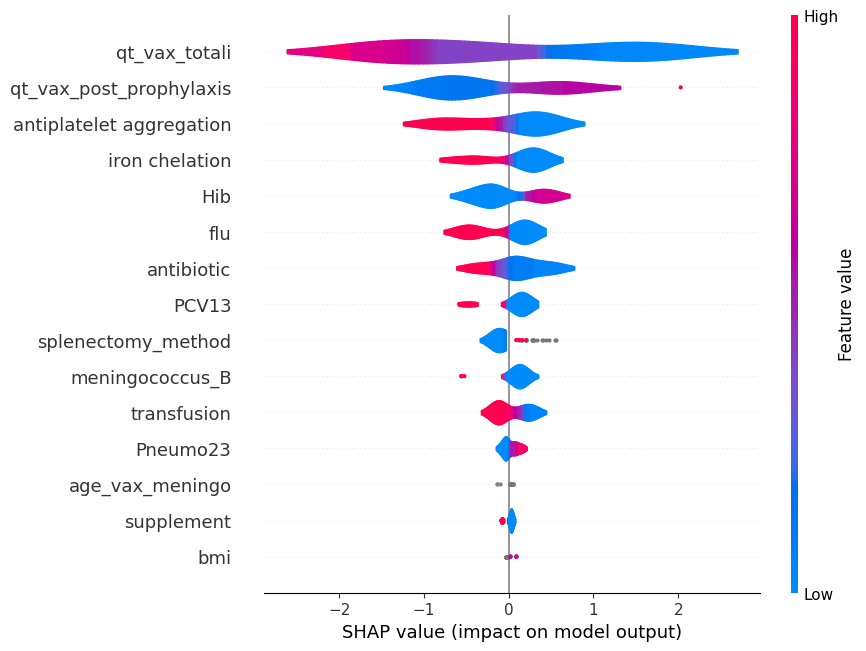

In [16]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer.shap_values(Xv_df)
shap.plots.violin(shap_values, features=Xv_df, feature_names=Xv_df.columns,max_display=15)


## Heatmaps

In [17]:
from cv_folding import lgbm_cv
results_df, model, X_df, Xv_df, y_train, y_test, results = lgbm_cv(embedder_configs, y_df, selected_ids, methods=["COUNTER"], 
                                                                   random_state=seed, return_metrics=True)
results_df

,AUC mean,AUC std,F1 mean,F1 std,Prec mean,Prec std,Recall mean,Recall std,MCC mean,MCC std,Acc mean,Acc std,Brier,CM
COUNTER,0.843933,0.056505,0.736781,0.076436,0.722497,0.092717,0.754286,0.066911,0.594474,0.126096,0.813953,0.062402,0.167916,"[[120, 22], [18, 55]]"


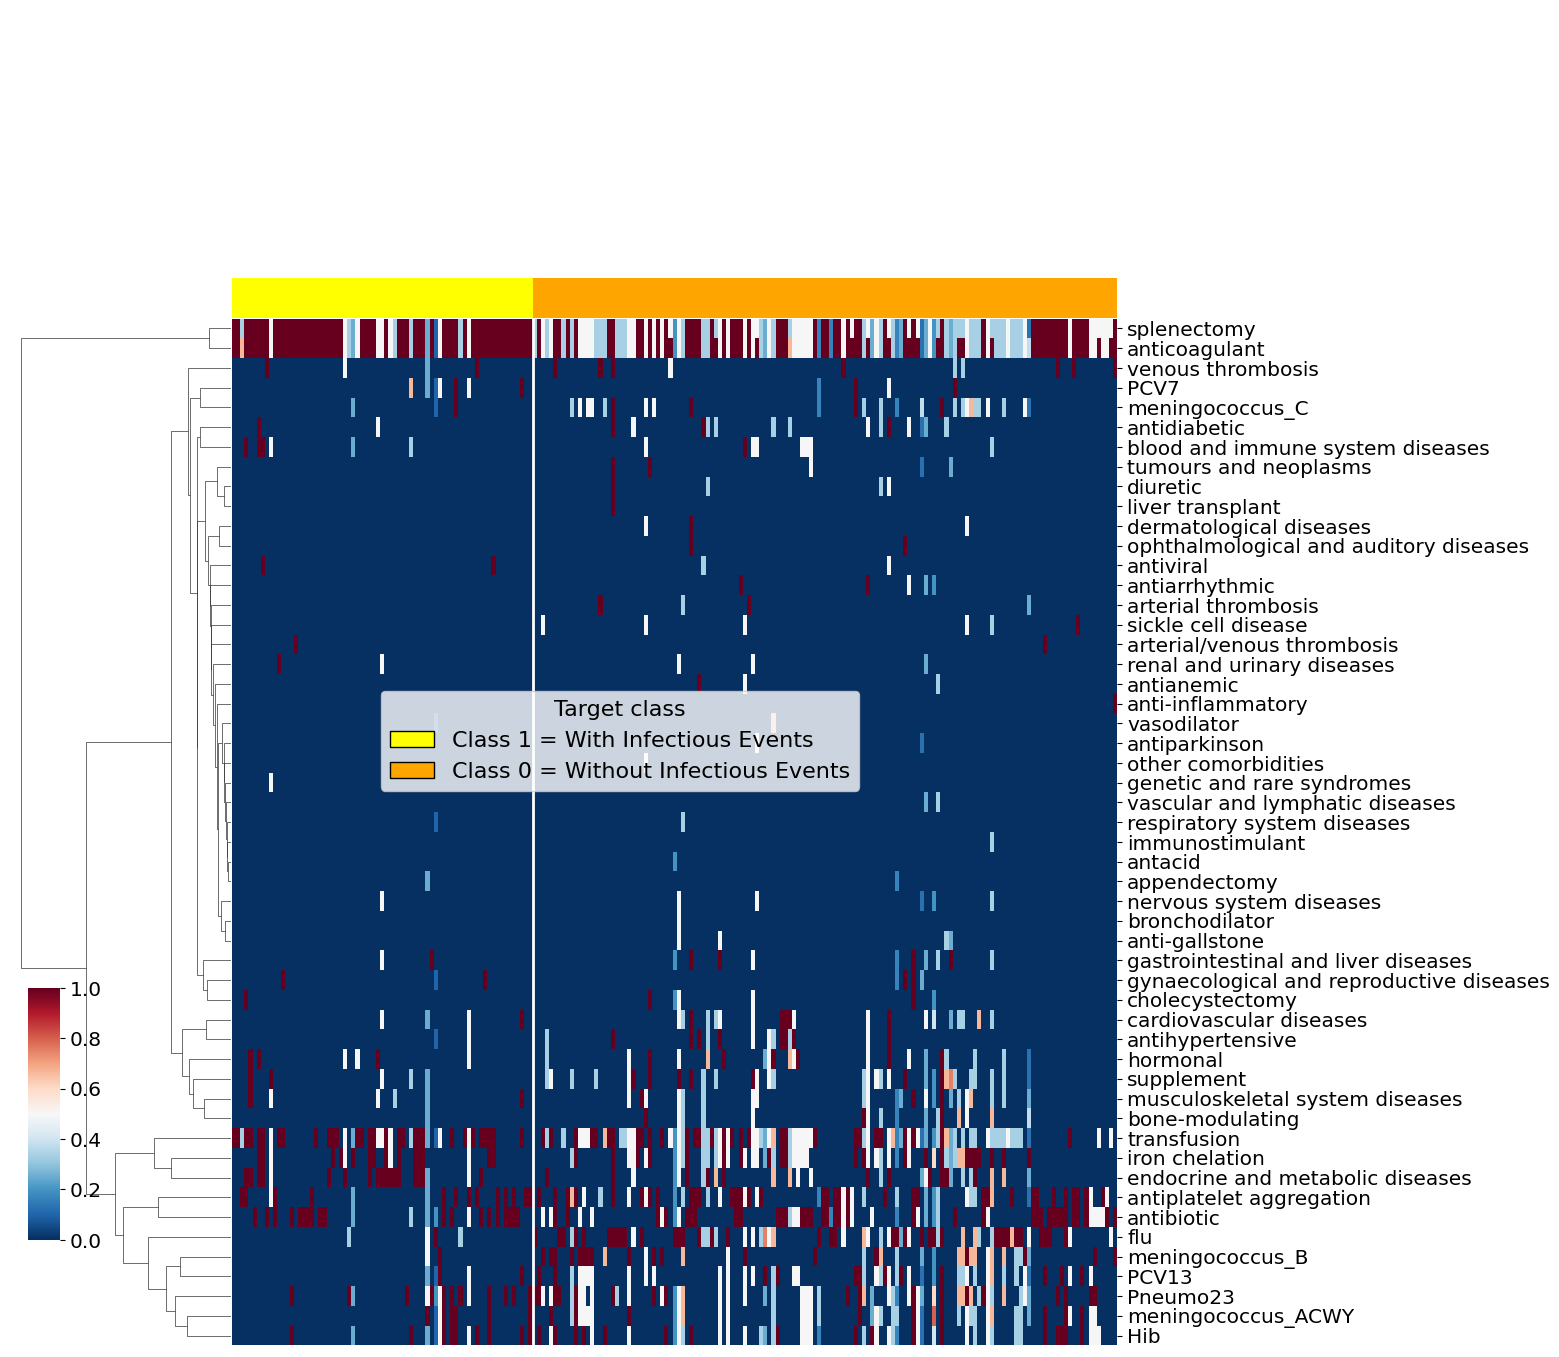

In [18]:
from plotting import plot_heatmap

plot_heatmap(X_df, y_df, Xv_df)

# Statistical Analysis

In [19]:
import pandas as pd
import pickle
import itertools
from scipy.stats import friedmanchisquare, wilcoxon
import statsmodels.stats.multitest as smm

# ======================
# LOAD DATA
# ======================
with open(f"{results_dir}/rawmeas_{niter}iter_{groupname}{subgroup}.pkl", 'rb') as f:
    ff = pickle.load(f)
df = pd.DataFrame({m: ff['MCC'][m] for m in methods})
df

,STATIC,BINARY,DOME,LSTM,tLSTM,GRU,GRU-D,BEHRT,RETAIN,Dipole
0,0.757759,0.894089,0.799908,0.697233,0.488964,0.413303,0.843833,0.741027,0.634648,0.688091
1,0.576355,0.845158,0.859265,0.741027,0.557327,0.636895,0.784811,0.799908,0.579575,0.682266
2,0.550184,0.741262,0.632476,0.686891,0.486867,0.527807,0.632476,0.605766,0.632476,0.582990
3,0.550184,0.580645,0.636895,0.589245,0.465540,0.636895,0.752101,0.741262,0.580645,0.605766
4,0.466944,0.547003,0.446054,0.605766,0.495595,0.429587,0.338118,0.374166,0.385714,0.527843


### Wiloxon pair-wise test

In [20]:
from stats import friedman_test, wilcoxon_test
stat, p = friedman_test(df)
result_df, wilcoxon_reject, wilcoxon_p_corr = wilcoxon_test(df,stat)


=== FRIEDMAN TEST ===
Statistic: 18.5165
p-value: 0.029633
➡️ SIGNIFICANT global differences

WILCOXON PAIRWISE POST-HOC + HOLM
wins❌ no significant pair after Holm's correction

Detailed Wilcoxon report:
     STATIC vs BINARY   | raw p = 0.062500 | Holm p = 1.000000
     STATIC vs DOME     | raw p = 0.125000 | Holm p = 1.000000
     STATIC vs LSTM     | raw p = 0.187500 | Holm p = 1.000000
     STATIC vs tLSTM    | raw p = 0.187500 | Holm p = 1.000000
     STATIC vs GRU      | raw p = 1.000000 | Holm p = 1.000000
     STATIC vs GRU-D    | raw p = 0.312500 | Holm p = 1.000000
     STATIC vs BEHRT    | raw p = 0.437500 | Holm p = 1.000000
     STATIC vs RETAIN   | raw p = 1.000000 | Holm p = 1.000000
     STATIC vs Dipole   | raw p = 0.437500 | Holm p = 1.000000
     BINARY vs DOME     | raw p = 0.312500 | Holm p = 1.000000
     BINARY vs LSTM     | raw p = 0.437500 | Holm p = 1.000000
     BINARY vs tLSTM    | raw p = 0.062500 | Holm p = 1.000000
     BINARY vs GRU      | raw p = 0.12

### Wilcoxon ranking (Win cout)

In [21]:
from stats import wilcoxon_ranking

wilcoxon_ranking(df, wilcoxon_reject)

,wins,losses,score
STATIC,0,0,0
BINARY,0,0,0
DOME,0,0,0
LSTM,0,0,0
tLSTM,0,0,0
GRU,0,0,0
GRU-D,0,0,0
BEHRT,0,0,0
RETAIN,0,0,0
Dipole,0,0,0


# Calibration analysis

In [22]:
import pickle
with open(f"{results_dir}/rawmeas_1iter_{groupname}{subgroup}.pkl", 'rb') as f:
    results = pickle.load(f)
prob_pred = {}
prob_true = {}
all_runs = {}
for method in methods:
    prob_pred[method] = results['calibration_prob_pred'][method]
    prob_true[method] = results['calibration_prob_true'][method]
    all_runs[method] = (results['y_true_oof'][method], results['y_prob_oof'][method])

### draw calibration curves

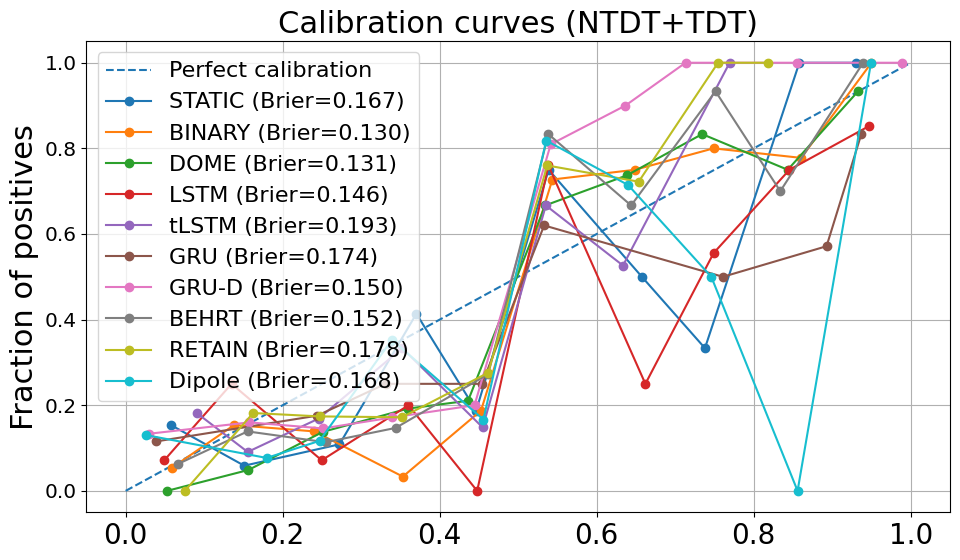

In [23]:
from plotting import plot_calibration

plot_calibration(prob_pred, prob_true,all_runs,title=f"Calibration curves ({groupname})")